In [1]:
import numpy as np
import json

from sklearn.datasets import make_multilabel_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

import plotly.graph_objects as go
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [3]:
def generate_data_set(params):
    inputs_, outputs_ = make_multilabel_classification(
        n_samples=params["sample_size"] + 1,
        n_classes=params["label_number"],
        n_labels=params["avg_label_number"],
        allow_unlabeled=False,
        return_indicator=True,
    )
    return inputs_, outputs_

In [4]:
def resample_data_set(inputs_, outputs_, params):
    sample_size = inputs_.shape[0] - 1
    indices = np.arange(sample_size + 1)
    np.random.shuffle(indices)

    inputs_ = inputs_[indices, :]
    outputs_ = outputs_[indices, :]

    inputs, outputs = (inputs_[:-1, :], outputs_[:-1, :])
    input_test, output_test = (
        inputs_[-1, :].reshape(1, -1),
        outputs_[-1, :].reshape(1, -1),
    )

    inputs_train, inputs_calibration, outputs_train, outputs_calibration = (
        train_test_split(inputs, outputs, test_size=params["cal_size"])
    )

    input_scaler = StandardScaler()
    scaled_inputs_train = input_scaler.fit_transform(inputs_train)
    scaled_inputs_calibration = input_scaler.transform(inputs_calibration)
    scaled_input_test = input_scaler.transform(input_test)

    (
        scaled_inputs_selection,
        scaled_inputs_proper_cal,
        outputs_selection,
        outputs_proper_cal,
    ) = train_test_split(
        scaled_inputs_calibration,
        outputs_calibration,
        test_size=params["proper_cal_size"],
    )

    return (
        (scaled_inputs_train, outputs_train),
        (scaled_inputs_calibration, outputs_calibration),
        (
            scaled_inputs_selection,
            scaled_inputs_proper_cal,
            outputs_selection,
            outputs_proper_cal,
        ),
        (scaled_input_test, output_test),
    )

## FNR risk

In [5]:
def make_FNR_risk(outputs, probas):
    sample_size = outputs.shape[0]

    def FNR_risk(q_value):
        return (
            (np.logical_and(outputs, probas < 1 - q_value)).sum(axis=1)
            / outputs.sum(axis=1)
        ).mean()

    def lower_FNR_risk(q_value):
        return (0.0 + sample_size * FNR_risk(q_value)) / (sample_size + 1)

    def upper_FNR_risk(q_value):
        return (1.0 + sample_size * FNR_risk(q_value)) / (sample_size + 1)

    return FNR_risk, lower_FNR_risk, upper_FNR_risk

## Level search

In [6]:
def dichotomy_search(func, change_points):
    cardinal = change_points.shape[0]
    left_index = 0
    right_index = cardinal - 1

    f_right = func(change_points[right_index])
    f_left = func(change_points[left_index])

    if f_right * f_left > 0:
        if f_left > 0:
            return right_index
        else:
            return left_index

    while (right_index - left_index) >= 2:
        middle_index = max(
            min(np.int64((left_index + right_index) / 2), right_index), left_index
        )
        f_middle = func(change_points[middle_index])

        # print("left", left_index, f_left)
        # print("middle", middle_index, f_middle)
        # print("right", right_index, f_right)

        if (f_middle == 0) or (f_left * f_middle < 0):
            right_index = middle_index
            f_right = f_middle
        else:
            left_index = middle_index
            f_left = f_middle

    if f_left * f_right < 0:
        return right_index
    else:
        return left_index

# One repetition of conformal risk-control

In [7]:
params_global = reader("params/synthetic.json")

{'data': {'sample_size': 1000, 'label_number': 10, 'avg_label_number': 4, 'cal_size': 0.5, 'proper_cal_size': 0.5}, 'predictor': {'log_lam_min': -2, 'log_lam_max': 4, 'lam_base': 10, 'lam_number': 100}, 'risk': {'control_level': 0.1}}


In [8]:
predictor = OneVsRestClassifier(
    LogisticRegression(C=1 / params_global["predictor"]["lam_base"])
)
inputs_, outputs_ = generate_data_set(params_global["data"])

In [9]:
(
    (scaled_inputs_train, outputs_train),
    (scaled_inputs_calibration, outputs_calibration),
    (
        scaled_inputs_selection,
        scaled_inputs_proper_cal,
        outputs_selection,
        outputs_proper_cal,
    ),
    (scaled_input_test, output_test),
) = resample_data_set(inputs_, outputs_, params_global["data"])

In [10]:
predictor.fit(scaled_inputs_train, outputs_train)

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",LogisticRegression(C=0.1)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
Name,Type,Value
"classes_ classes_: array, shape = [`n_classes`]Class labels.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
estimators_ estimators_: list of `n_classes` estimatorsEstimators used for predictions.,list,"[LogisticRegression(C=0.1), LogisticRegression(C=0.1), LogisticRegression(C=0.1), LogisticRegression(C=0.1), ...]"
label_binarizer_ label_binarizer_: LabelBinarizer objectObject used to transform multiclass labels to binary labels andvice-versa.,LabelBinarizer,LabelBinarize...e_output=True)
multilabel_ multilabel_: booleanWhether a OneVsRestClassifier is a multilabel classifier.,bool,True
n_classes_ n_classes_: intNumber of classes.,int,10
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,20
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1


In [11]:
probas_calibration = predictor.predict_proba(scaled_inputs_calibration)
proba_test = predictor.predict_proba(scaled_input_test)

In [12]:
FNR_risk, lower_FNR_risk, upper_FNR_risk = make_FNR_risk(
    outputs_calibration, probas_calibration
)
change_points_calibration = np.concatenate(
    ([0.0], np.sort(1 - probas_calibration.flatten()), [1.0])
)
upper_level_index = dichotomy_search(
    lambda q: (upper_FNR_risk(q) - params_global["risk"]["control_level"]),
    change_points_calibration,
)
upper_level = change_points_calibration[upper_level_index]
upper_fnr_risk_at_upper_level = upper_FNR_risk(upper_level)

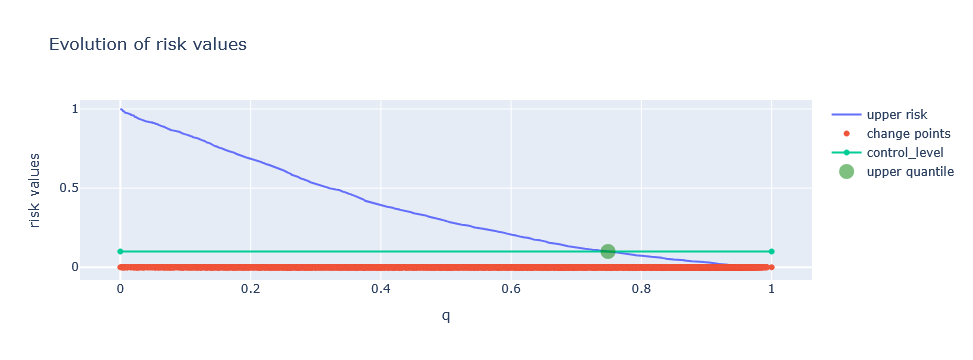

In [14]:
q_values = np.linspace(0, 1, 10000)
upper_fnr_risk_values = np.array([upper_FNR_risk(q_value) for q_value in q_values])
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=q_values,
        y=upper_fnr_risk_values,
        name="upper risk",
        # mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        # marker=dict(
        #     size=5,  # Set the marker size
        #     color="blue",  # Set the marker color
        #     opacity=0.8,  # Set the marker opacity
        # ),
    )
)

fig.add_trace(
    go.Scatter(
        x=change_points_calibration,
        y=np.zeros(change_points_calibration.size),
        name="change points",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        # marker=dict(
        #     size=5,  # Set the marker size
        #     color="blue",  # Set the marker color
        #     opacity=0.8,  # Set the marker opacity
        # ),
    )
)

fig.add_trace(
    go.Scatter(
        x=[change_points_calibration[0], change_points_calibration[-1]],
        y=[
            params_global["risk"]["control_level"],
            params_global["risk"]["control_level"],
        ],
        name="control_level",
    )
)

fig.add_trace(
    go.Scatter(
        x=[upper_level],
        y=[upper_fnr_risk_at_upper_level],
        name="upper quantile",
        mode="markers",  # Specify the marker mode ('markers' for scatter plot)
        marker=dict(
            size=15,  # Set the marker size
            color="green",  # Set the marker color
            opacity=0.5,  # Set the marker opacity
        ),
    )
)

fig.update_layout(
    title="Evolution of risk values",
    xaxis_title="q",
    yaxis_title="risk values",
)
fig.show()

In [15]:
fnr_test = (np.logical_and(output_test, proba_test < 1 - upper_level)).sum(
    axis=1
) / output_test.sum(axis=1)
prediction_set_size_test = (proba_test >= 1 - upper_level).sum(axis=1)
print("The fnr at the test point is {}.".format(fnr_test.item()))
print(
    "The prediction-set size at the test point is {}.".format(
        prediction_set_size_test.item()
    )
)

The fnr at the test point is 0.0.
The prediction-set size at the test point is 7.


# Multi repetition of conformal risk-control

In [16]:
predictor = OneVsRestClassifier(
    LogisticRegression(C=1 / params_global["predictor"]["lam_base"])
)
inputs_, outputs_ = generate_data_set(params_global["data"])

fnrs_test = []
prediction_set_sizes_test = []

rep_number = 1000
for rep_index in tqdm(range(rep_number)):
    (
        (scaled_inputs_train, outputs_train),
        (scaled_inputs_calibration, outputs_calibration),
        (
            scaled_inputs_selection,
            scaled_inputs_proper_cal,
            outputs_selection,
            outputs_proper_cal,
        ),
        (scaled_input_test, output_test),
    ) = resample_data_set(inputs_, outputs_, params_global["data"])

    predictor.fit(scaled_inputs_train, outputs_train)

    probas_calibration = predictor.predict_proba(scaled_inputs_calibration)
    proba_test = predictor.predict_proba(scaled_input_test)

    FNR_risk, lower_FNR_risk, upper_FNR_risk = make_FNR_risk(
        outputs_calibration, probas_calibration
    )
    change_points_calibration = np.concatenate(
        ([0.0], np.sort(1 - probas_calibration.flatten()), [1.0])
    )
    upper_level_index = dichotomy_search(
        lambda q: (upper_FNR_risk(q) - params_global["risk"]["control_level"]),
        change_points_calibration,
    )
    upper_level = change_points_calibration[upper_level_index]

    fnr_test = (np.logical_and(output_test, proba_test < 1 - upper_level)).sum(
        axis=1
    ) / output_test.sum(axis=1)
    prediction_set_size_test = (proba_test >= 1 - upper_level).sum(axis=1)

    fnrs_test.append(fnr_test.item())
    prediction_set_sizes_test.append(prediction_set_size_test.item())

100%|██████████| 1000/1000 [00:35<00:00, 28.01it/s]


In [17]:
params_global["risk"]["control_level"]

0.1

In [18]:
empirical_risk = np.mean(fnrs_test)
print("the empirical risk is {}".format(empirical_risk))
empirical_loss_std = np.std(fnrs_test)
print("the empirical std is {}".format(empirical_loss_std))

the empirical risk is 0.0998388888888889
the empirical std is 0.13978315570616368


(0.0, 10.2)

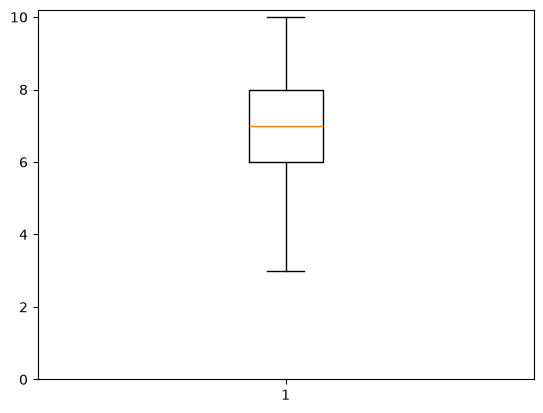

In [19]:
fig, ax = plt.subplots()
ax.boxplot(prediction_set_sizes_test)
ax.set_ylim(0, 10.2)

(-0.1, 1.0)

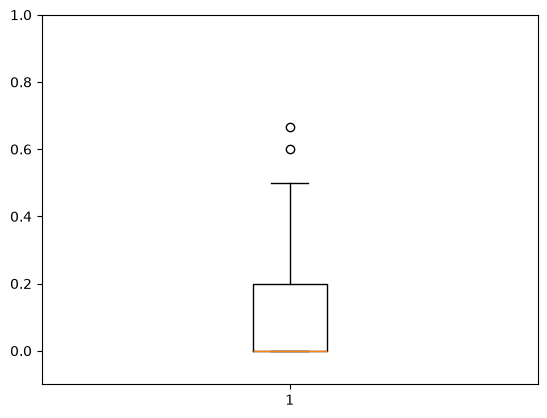

In [20]:
fig, ax = plt.subplots()
ax.boxplot(fnrs_test)
ax.set_ylim(-0.1, 1)